# Actividad 2 (Analisis Univariado-Socio Formador) II

## Isaac Barron - A01737199

#### Crear un nuevo repositorio con el nombre: Actividad 2 (Análisis Univariado-Socio Formador)
#### Agregar el archivo: El archivo Datos_CLV_2026_Tec_v2.xlsx
#### Realiza las acciones de preprocesamiento necesarias: Nulos y Outliers
#### Extraer características estadísticas a partir de un análisis univariado, a las siguientes variables categóricas del archivo correspondiente. Mostrar los resultados obtenidos ,mediante gráficas y tablas.

In [28]:
#importar librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
#cargar datos y seleccionar columnas a trata: Ventas_Negadas_CRM y Metas

Vnegadas = pd.read_excel("Datos_CLV_2026_Tec_v2.xlsx", sheet_name="Ventas_Negadas_CRM")
metas = pd.read_excel("Datos_CLV_2026_Tec_v2.xlsx", sheet_name="Metas")

#imprimir ambos df
print(Vnegadas, metas)

       id_negocio    nombre_etapa            estado  estatus  \
0     60966213634   Cierre Ganado         Querétaro  Cerrado   
1     60964805197  Cierre Perdido         Querétaro  Cerrado   
2     60964799543   Cierre Ganado         Querétaro  Cerrado   
3     60964785012   Cierre Ganado         Querétaro  Cerrado   
4     60962206830   Cierre Ganado         Querétaro  Cerrado   
...           ...             ...               ...      ...   
5263  56289503329   Cierre Ganado  Ciudad De México  Cerrado   
5264  56289509963   Cierre Ganado  Ciudad De México  Cerrado   
5265  56289625889   Cierre Ganado           Hidalgo  Cerrado   
5266  62047704902   Cierre Ganado               NaN  Cerrado   
5267  56358579734   Cierre Ganado  Ciudad De México  Cerrado   

                fecha_creacion              fecha_cierre motivo_cierre_perdido  
0     2026-06-08T21:50:42.257Z  2026-06-08T22:53:13.159Z                   NaN  
1     2026-06-09T00:12:48.684Z  2026-06-24T20:39:32.277Z    No tiene 

In [30]:
Vnegadas.info()

<class 'pandas.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id_negocio             5268 non-null   int64
 1   nombre_etapa           5268 non-null   str  
 2   estado                 5099 non-null   str  
 3   estatus                5268 non-null   str  
 4   fecha_creacion         5268 non-null   str  
 5   fecha_cierre           5206 non-null   str  
 6   motivo_cierre_perdido  865 non-null    str  
dtypes: int64(1), str(6)
memory usage: 707.3 KB


In [31]:
metas.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meta_id   756 non-null    int64  
 1   dia       756 non-null    int64  
 2   mes       756 non-null    int64  
 3   anio      756 non-null    int64  
 4   fecha     756 non-null    str    
 5   fecha_id  756 non-null    int64  
 6   estado    756 non-null    str    
 7   meta      756 non-null    float64
dtypes: float64(1), int64(5), str(2)
memory usage: 69.1 KB


# Hoja: Ventas_Negadas_CRM

In [32]:
#identificar valores nulos por columna en df
nulosvnegadas = Vnegadas.isnull().sum()
nulosvnegadas

id_negocio                  0
nombre_etapa                0
estado                    169
estatus                     0
fecha_creacion              0
fecha_cierre               62
motivo_cierre_perdido    4403
dtype: int64

In [33]:
#imprimir valores unicos de la columna estado, fecha_cierre y motivo_cierre_perdido
print(Vnegadas['estado'].unique())
print(Vnegadas['fecha_cierre'].unique())
print(Vnegadas['motivo_cierre_perdido'].unique())

<ArrowStringArray>
[          'Querétaro',             'Hidalgo',           'Chihuahua',
                   nan,              'Sonora',          'Guanajuato',
     'San Luis Potosí',          'Nuevo León',              'Oaxaca',
          'Tamaulipas',            'Coahuila',    'Estado De México',
    'Ciudad De México',             'Chiapas',             'Morelos',
            'Guerrero',             'Jalisco',             'Sinaloa',
      'Aguascalientes',              'Puebla',             'Yucatán',
        'Quintana Roo',             'Tabasco',            'Tlaxcala',
            'Veracruz',            'Campeche',           'Zacatecas',
           'Michoacán',             'Durango',             'Nayarit',
              'Colima', 'Baja California Sur',     'Baja California']
Length: 33, dtype: str
<ArrowStringArray>
['2026-06-08T22:53:13.159Z', '2026-06-24T20:39:32.277Z',
  '2026-06-24T22:13:35.26Z',  '2026-06-09T22:22:07.18Z',
  '2026-06-08T21:06:47.96Z', '2026-07-03T15:30:32.623Z'

3 Columnas con nulos, según la descripción del diccionario de datos son columnas opcionales de llenado y que en ocaciones no aplican para insertar algun valor de captura, se propone input según la categoría. 

In [34]:
#inputar valores nulos de la columna estado con el valor "Desconocido"
Vnegadas['estado'] = Vnegadas['estado'].fillna('Desconocido')

# Verificar que ya no haya valores nulos en la columna
Vnegadas['estado'].isnull().sum()

np.int64(0)

In [35]:
#inputar valores nulos de la columna fecha_cierre con forward fill
Vnegadas['fecha_cierre'] = Vnegadas['fecha_cierre'].ffill()

# Verificar que ya no haya valores nulos en la columna
Vnegadas['fecha_cierre'].isnull().sum()

np.int64(0)

In [36]:
# inputar valores nulos de la columna motivo_cierre_perdido con el valor "Desconocido"
Vnegadas['motivo_cierre_perdido'] = Vnegadas['motivo_cierre_perdido'].fillna('Desconocido')

# Verificar que ya no haya valores nulos en la columna
Vnegadas['motivo_cierre_perdido'].isnull().sum()

np.int64(0)

Los valores de la columna motivo_cierre_perdido son unicamente 8 distintos, contienen una pequela frase que puede ser resumida a una palabra, mi propuesta es estadarizar los motivos a modo de poder utilizarlos para algun algoritmo posteriormente.

In [37]:
# Estandarizar los motivos de cierre; los valores no incluidos se conservan
motivos = {
    'No tiene el dinero': 'Insolvente',
    'No pasó su crédito (Financiera)': 'Financiera',
    'Eligio un producto de la competencia': 'Deserción',
    'Falta de producto': 'Inventario',
    'Sin interés detectado': 'Desinteres',
    'Sin Respuesta': 'Srespuesta',
    'No paso su credito': 'Cdenegado'
}

Vnegadas['motivo_cierre_perdido'] = Vnegadas['motivo_cierre_perdido'].replace(motivos)

# Revisar los valores resultantes
Vnegadas['motivo_cierre_perdido'].value_counts()

motivo_cierre_perdido
Desconocido    4403
Insolvente      301
Inventario      267
Srespuesta      152
Desinteres       72
Deserción        47
Financiera       14
Cdenegado        12
Name: count, dtype: int64

In [38]:
#verificar Vnegafas final 
Vnegadas.head(10)

,id_negocio,nombre_etapa,estado,estatus,fecha_creacion,fecha_cierre,motivo_cierre_perdido
0,60966213634,Cierre Ganado,Querétaro,Cerrado,2026-06-08T21:50:42.257Z,2026-06-08T22:53:13.159Z,Desconocido
1,60964805197,Cierre Perdido,Querétaro,Cerrado,2026-06-09T00:12:48.684Z,2026-06-24T20:39:32.277Z,Insolvente
2,60964799543,Cierre Ganado,Querétaro,Cerrado,2026-06-08T22:20:22.148Z,2026-06-24T22:13:35.26Z,Desconocido
3,60964785012,Cierre Ganado,Querétaro,Cerrado,2026-06-08T19:06:34.126Z,2026-06-09T22:22:07.18Z,Desconocido
4,60962206830,Cierre Ganado,Querétaro,Cerrado,2026-06-08T18:23:55.735Z,2026-06-08T21:06:47.96Z,Desconocido
5,60962198894,Cierre Perdido,Hidalgo,Cerrado,2026-06-08T17:39:24Z,2026-07-03T15:30:32.623Z,Insolvente
6,60864464165,Cierre Perdido,Querétaro,Cerrado,2026-06-04T17:31:39.113Z,2026-07-07T15:17:04.251Z,Financiera
7,60786207900,Perdido,Chihuahua,Cerrado,2026-06-02T23:01:28.135Z,2026-08-17T20:39:10.839Z,Insolvente
8,61917246634,Cierre Ganado,Desconocido,Cerrado,2026-06-30T22:43:48.612Z,2026-06-30T23:35:14.836Z,Desconocido
9,60785654045,Cierre Perdido,Sonora,Cerrado,2026-06-02T22:57:16.318Z,2026-07-30T18:03:06.927Z,Deserción


Proceso de nulos y ouliers finalizado para Ventas_Negadas_CRM

nota: no se aplico ninguna evaluación de ouliers debido a la naturaleza categórica de los datos y la carencia de valores cuantitativos 

# Hoja: Metas

In [39]:
#identificaar valores nulos por columna en metas
metas.isnull().sum()


meta_id     0
dia         0
mes         0
anio        0
fecha       0
fecha_id    0
estado      0
meta        0
dtype: int64

No existen valores nulos en metas

In [ ]:
#evaluar outliers en la columna metas['meta'] usando boxplot (solo se evalua esta columna ya que es la unica numerica)




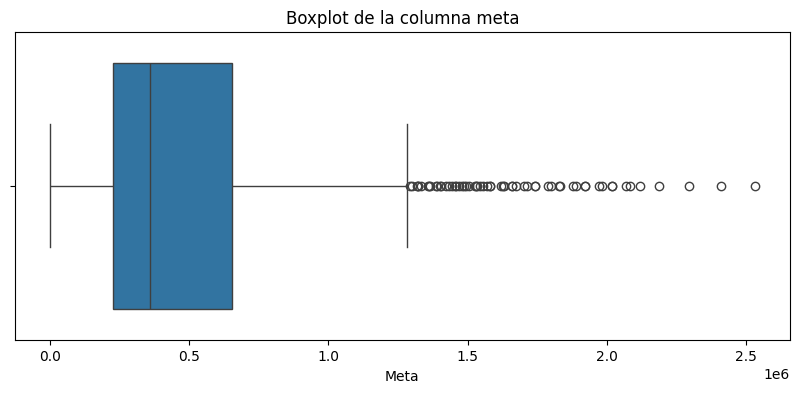

Q1: 227,213.44
Q3: 652,331.82
IQR: 425,118.38
Límite inferior: -410,464.12
Límite superior: 1,290,009.38
Número de outliers: 60


,estado,fecha,meta
473,Baja California,2025-08-01T00:00:00Z,1.291626e+06
155,Jalisco,2026-03-01T00:00:00Z,1.300950e+06
158,Baja California,2025-03-01T00:00:00Z,1.319846e+06
189,Baja California,2026-04-01T00:00:00Z,1.322200e+06
172,Ciudad De México,2025-03-01T00:00:00Z,1.323000e+06
144,Puebla,2026-03-01T00:00:00Z,1.334025e+06
536,Baja California,2025-09-01T00:00:00Z,1.356207e+06
252,Baja California,2026-05-01T00:00:00Z,1.361866e+06
218,Jalisco,2026-04-01T00:00:00Z,1.365998e+06
221,Baja California,2025-04-01T00:00:00Z,1.385838e+06


In [42]:
# Boxplot de la columna meta
plt.figure(figsize=(10, 4))
sns.boxplot(x=metas['meta'])
plt.title('Boxplot de la columna meta')
plt.xlabel('Meta')
plt.show()

# Identificar outliers con el método IQR
Q1 = metas['meta'].quantile(0.25)
Q3 = metas['meta'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = metas[
    (metas['meta'] < limite_inferior) |
    (metas['meta'] > limite_superior)
]

print(f"Q1: {Q1:,.2f}")
print(f"Q3: {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")
print(f"Límite inferior: {limite_inferior:,.2f}")
print(f"Límite superior: {limite_superior:,.2f}")
print(f"Número de outliers: {len(outliers)}")

outliers[['estado', 'fecha', 'meta']].sort_values('meta')

Aunque la evaluación nos haya arrojado diversos outliers se recomienda no remplazarlos, el principal motivo es que representan metas de venta, modificarlas afectaría cualquier evaluación posterior de su cumplimiento.

# Análisis univariado 

# EDA general 

Exploración inicial de las hojas Ventas_Negadas_CRM y Metas para tener un panorama general y detectar patrones. El objetivo es entender los datos, no modelarlos todavía.



In [ ]:
#  Preparación para el EDA: se trabaja sobre COPIAS, el preprocesamiento anterior no se modifica 
AZUL, NARANJA, GRIS = '#2a78d6', '#eb6834', '#9a9a95'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True,
                     'axes.titleweight': 'bold', 'axes.titlelocation': 'left'})

vn = Vnegadas.copy()
vn['fecha_creacion'] = pd.to_datetime(vn['fecha_creacion'], utc=True, format='ISO8601')
vn['fecha_cierre'] = pd.to_datetime(vn['fecha_cierre'], utc=True, format='ISO8601')

# Resultado del negocio a partir de la etapa ("Ganado" y "Cierre Ganado" son equivalentes, igual con Perdido)
def resultado(etapa):
    if 'Ganado' in etapa:
        return 'Ganado'
    if 'Perdido' in etapa:
        return 'Perdido'
    return 'Sin resultado'
vn['resultado'] = vn['nombre_etapa'].apply(resultado)

# Días entre creación y cierre: solo en negocios cerrados (en los abiertos la fecha se rellenó con ffill)
vn['dias_cierre'] = (vn['fecha_cierre'] - vn['fecha_creacion']).dt.total_seconds() / 86400
vn.loc[vn['estatus'] != 'Cerrado', 'dias_cierre'] = np.nan

mt = metas.copy()
mt['estado'] = mt['estado'].str.strip()      # en Metas existe 'Nuevo León ' con un espacio al final
mt['fecha'] = pd.to_datetime(mt['fecha'], utc=True)
mt['periodo'] = mt['fecha'].dt.strftime('%Y-%m')

In [ ]:
# Panorama general de ambas hojas
resumen = pd.DataFrame({
    'Ventas_Negadas_CRM': [
        Vnegadas.shape[0], Vnegadas.shape[1], vn['id_negocio'].duplicated().sum(),
        vn.loc[vn['estado'] != 'Desconocido', 'estado'].nunique(),
        f"{vn['fecha_creacion'].min():%Y-%m-%d} a {vn['fecha_creacion'].max():%Y-%m-%d}"],
    'Metas': [
        metas.shape[0], metas.shape[1], mt.duplicated(['estado', 'fecha']).sum(),
        mt['estado'].nunique(),
        f"{mt['fecha'].min():%Y-%m-%d} a {mt['fecha'].max():%Y-%m-%d}"],
}, index=['Filas', 'Columnas', 'Duplicados (id_negocio / estado+fecha)', 'Estados distintos',
          'Rango de fechas (creación / meta)'])
resumen

,Ventas_Negadas_CRM,Metas
Filas,5268,756
Columnas,7,8
Duplicados (id_negocio / estado+fecha),0,0
Estados distintos,32,32
Rango de fechas (creación / meta),2025-08-05 a 2026-09-04,2025-01-01 a 2026-12-01


## EDA - Ventas_Negadas_CRM

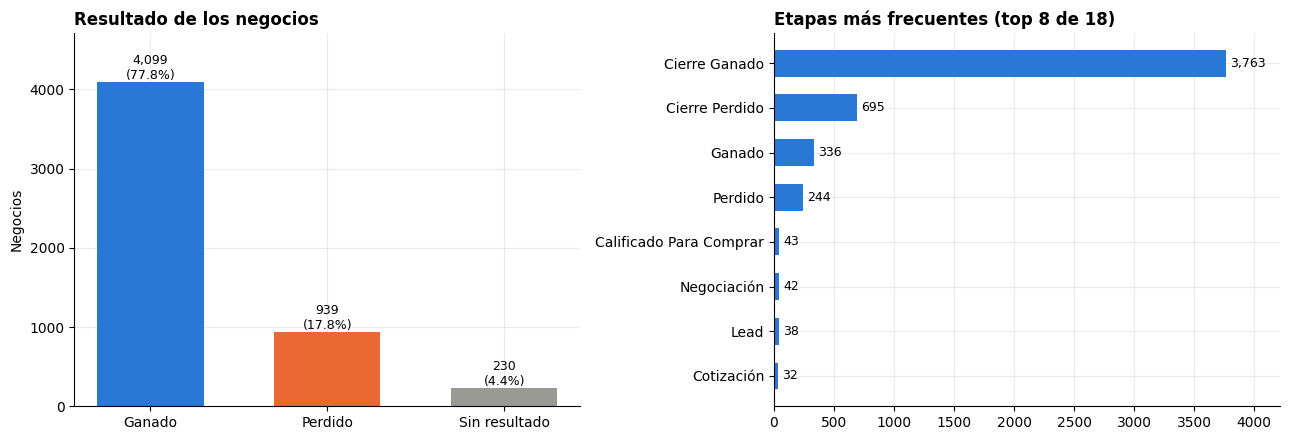

Tasa de negocios ganados sobre ganados+perdidos: 81.4%
Negocios aún abiertos: 228 (4.3%)


In [ ]:
# 1. Resultado de los negocios y etapas del embudo
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

res = vn['resultado'].value_counts()
b = axes[0].bar(res.index, res.values, color=[AZUL, NARANJA, GRIS], width=0.6)
axes[0].bar_label(b, labels=[f'{v:,}\n({v / len(vn):.1%})' for v in res.values], fontsize=9)
axes[0].set_title('Resultado de los negocios')
axes[0].set_ylabel('Negocios')
axes[0].set_ylim(0, res.max() * 1.15)

etapas = vn['nombre_etapa'].value_counts().head(8).sort_values()
axes[1].barh(etapas.index, etapas.values, color=AZUL, height=0.6)
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', fontsize=9, padding=3)
axes[1].set_title('Etapas más frecuentes (top 8 de 18)')
axes[1].set_xlim(0, etapas.max() * 1.12)
plt.tight_layout()
plt.show()

cerrados = vn[vn['resultado'].isin(['Ganado', 'Perdido'])]
print(f"Tasa de negocios ganados sobre ganados+perdidos: {(cerrados['resultado'] == 'Ganado').mean():.1%}")
print(f"Negocios aún abiertos: {(vn['estatus'] == 'Abierto').sum()} ({(vn['estatus'] == 'Abierto').mean():.1%})")

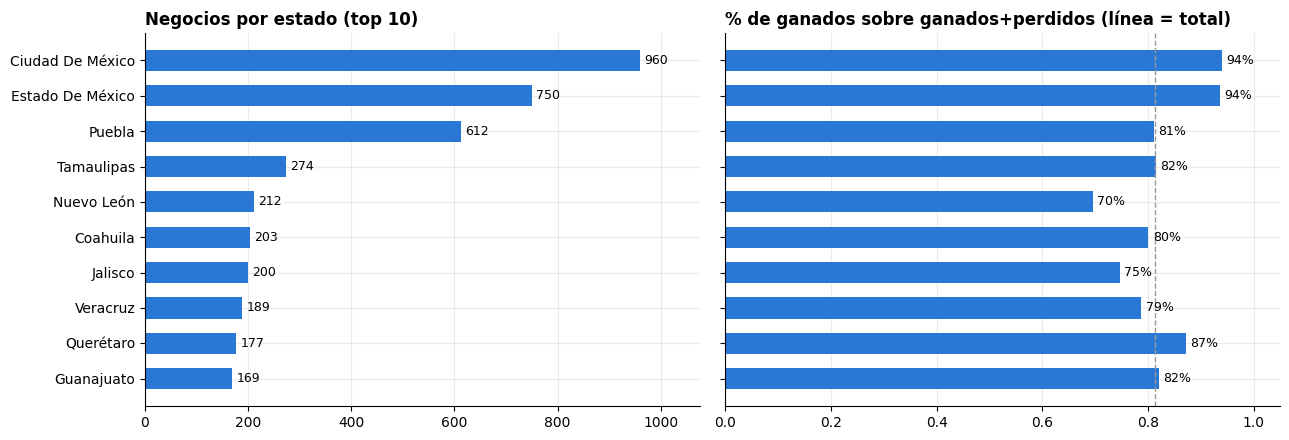

El top 10 concentra el 73.5% de los negocios con estado conocido
Negocios sin estado ('Desconocido'): 169


In [ ]:
# 2. Distribución geográfica: negocios por estado y % de ganados
top_estados = vn.loc[vn['estado'] != 'Desconocido', 'estado'].value_counts().head(10)
tasa = (cerrados[cerrados['estado'].isin(top_estados.index)]
        .groupby('estado')['resultado'].apply(lambda s: (s == 'Ganado').mean())
        .reindex(top_estados.index))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
orden = top_estados.index[::-1]
axes[0].barh(orden, top_estados[orden], color=AZUL, height=0.6)
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}', fontsize=9, padding=3)
axes[0].set_title('Negocios por estado (top 10)')
axes[0].set_xlim(0, top_estados.max() * 1.12)

axes[1].barh(orden, tasa[orden], color=AZUL, height=0.6)
axes[1].bar_label(axes[1].containers[0], labels=[f'{v:.0%}' for v in tasa[orden]], fontsize=9, padding=3)
axes[1].axvline((cerrados['resultado'] == 'Ganado').mean(), color=GRIS, ls='--', lw=1)
axes[1].set_title('% de ganados sobre ganados+perdidos (línea = total)')
axes[1].set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

top10_share = top_estados.sum() / vn.loc[vn['estado'] != 'Desconocido'].shape[0]
print(f"El top 10 concentra el {top10_share:.1%} de los negocios con estado conocido")
print(f"Negocios sin estado ('Desconocido'): {(vn['estado'] == 'Desconocido').sum()}")

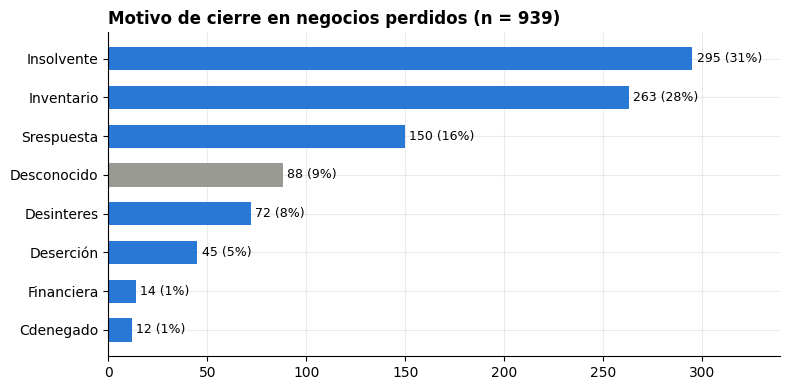

Perdidos sin motivo registrado: 88
motivo_cierre_perdido
Insolvente    0.347
Inventario    0.309
Srespuesta    0.176
Name: proportion, dtype: float64


In [ ]:
# 3. Motivos de pérdida (solo negocios perdidos)
perdidos = vn[vn['resultado'] == 'Perdido']
motivos_p = perdidos['motivo_cierre_perdido'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colores = [GRIS if m == 'Desconocido' else AZUL for m in motivos_p.index]
ax.barh(motivos_p.index, motivos_p.values, color=colores, height=0.6)
ax.bar_label(ax.containers[0], labels=[f'{v} ({v / len(perdidos):.0%})' for v in motivos_p.values], fontsize=9, padding=3)
ax.set_title(f'Motivo de cierre en negocios perdidos (n = {len(perdidos)})')
ax.set_xlim(0, motivos_p.max() * 1.15)
plt.tight_layout()
plt.show()

conocidos = perdidos[perdidos['motivo_cierre_perdido'] != 'Desconocido']
print(f"Perdidos sin motivo registrado: {(perdidos['motivo_cierre_perdido'] == 'Desconocido').sum()}")
print(conocidos['motivo_cierre_perdido'].value_counts(normalize=True).round(3).head(3))

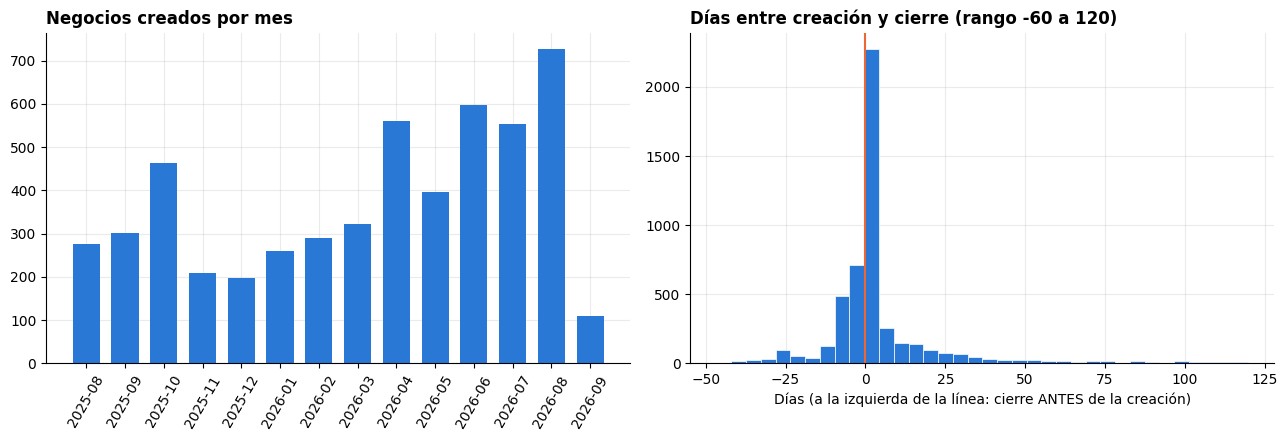

Fuera del rango graficado: 72 negocios
count    5040.0
mean        5.1
std        58.2
min     -3629.0
25%        -2.0
50%         0.0
75%         3.0
max       365.2
Name: dias_cierre, dtype: float64

Cierres con fecha anterior a la creación: 2116 de 5040 (42.0%)
Mediana de días (solo cierres >= 0): 1.6
Fecha de cierre mínima / máxima: 2015-10-26 / 2027-02-03


In [ ]:
# 4. Comportamiento en el tiempo: negocios creados por mes y días hasta el cierre
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

por_mes = vn['fecha_creacion'].dt.strftime('%Y-%m').value_counts().sort_index()
axes[0].bar(por_mes.index, por_mes.values, color=AZUL, width=0.7)
axes[0].set_title('Negocios creados por mes')
axes[0].tick_params(axis='x', rotation=60)

dias = vn['dias_cierre'].dropna()
axes[1].hist(dias[dias.between(-60, 120)], bins=36, color=AZUL, edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color=NARANJA, lw=1.5)
axes[1].set_title('Días entre creación y cierre (rango -60 a 120)')
axes[1].set_xlabel('Días (a la izquierda de la línea: cierre ANTES de la creación)')
plt.tight_layout()
plt.show()

print(f"Fuera del rango graficado: {(~dias.between(-60, 120)).sum()} negocios")
print(dias.describe().round(1))
print(f"\nCierres con fecha anterior a la creación: {(dias < 0).sum()} de {len(dias)} ({(dias < 0).mean():.1%})")
print(f"Mediana de días (solo cierres >= 0): {dias[dias >= 0].median():.1f}")
print(f"Fecha de cierre mínima / máxima: {vn['fecha_cierre'].min():%Y-%m-%d} / {vn['fecha_cierre'].max():%Y-%m-%d}")

## EDA - Metas

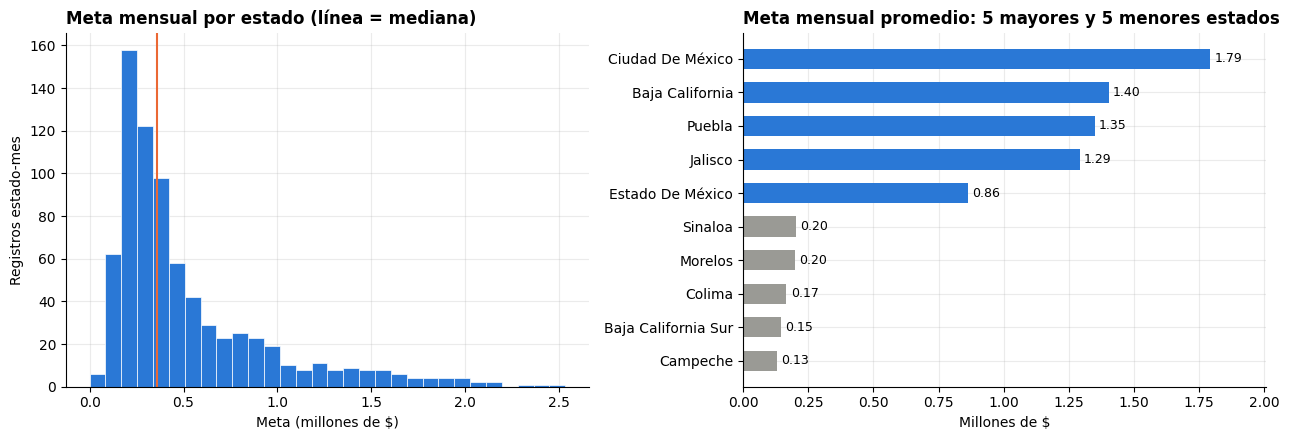

count          756
mean       520,376
std        432,725
min              0
25%        227,213
50%        358,864
75%        652,332
max      2,531,302
Name: meta, dtype: str

Media / mediana = 1.45  (asimetría positiva: pocos estados con metas muy grandes)
Los 5 estados con mayor meta suman el 40.9% de la meta total

Metas iguales a 0:
 estado periodo
Nayarit 2025-07
Nayarit 2025-08


In [ ]:
# 5. Distribución de la meta y diferencias entre estados
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(mt['meta'] / 1e6, bins=30, color=AZUL, edgecolor='white', linewidth=0.5)
axes[0].axvline(mt['meta'].median() / 1e6, color=NARANJA, lw=1.5)
axes[0].set_title('Meta mensual por estado (línea = mediana)')
axes[0].set_xlabel('Meta (millones de $)')
axes[0].set_ylabel('Registros estado-mes')

prom = mt.groupby('estado')['meta'].mean().sort_values(ascending=False)
sel = pd.concat([prom.head(5), prom.tail(5)])[::-1]
axes[1].barh(sel.index, sel.values / 1e6, color=[AZUL if v >= prom.iloc[4] else GRIS for v in sel.values], height=0.6)
axes[1].bar_label(axes[1].containers[0], labels=[f'{v / 1e6:.2f}' for v in sel.values], fontsize=9, padding=3)
axes[1].set_title('Meta mensual promedio: 5 mayores y 5 menores estados')
axes[1].set_xlabel('Millones de $')
axes[1].set_xlim(0, sel.max() / 1e6 * 1.12)
plt.tight_layout()
plt.show()

print(mt['meta'].describe().apply(lambda x: f'{x:,.0f}'))
print(f"\nMedia / mediana = {mt['meta'].mean() / mt['meta'].median():.2f}  (asimetría positiva: pocos estados con metas muy grandes)")
print(f"Los 5 estados con mayor meta suman el {mt[mt['estado'].isin(prom.head(5).index)]['meta'].sum() / mt['meta'].sum():.1%} de la meta total")
print("\nMetas iguales a 0:")
print(mt.loc[mt['meta'] == 0, ['estado', 'periodo']].to_string(index=False))

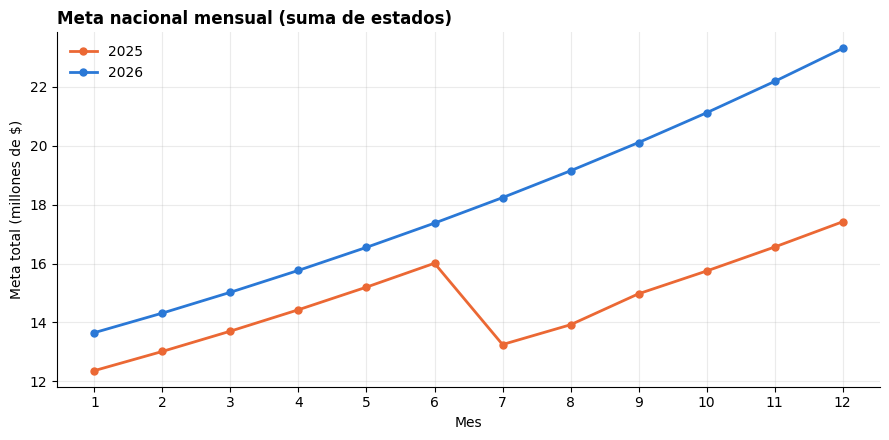

anio
2025    176,614,478
2026    216,789,510
Name: meta, dtype: str
Crecimiento de la meta anual 2026 vs 2025: 22.7%
Meta 2025 junio -> julio: 16.0 -> 13.3 millones


In [ ]:
# 6. Meta nacional mensual: 2025 vs 2026
nacional = mt.groupby(['anio', 'mes'])['meta'].sum().unstack(0) / 1e6

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(nacional.index, nacional[2025], color=NARANJA, lw=2, marker='o', ms=5, label='2025')
ax.plot(nacional.index, nacional[2026], color=AZUL, lw=2, marker='o', ms=5, label='2026')
ax.set_xticks(range(1, 13))
ax.set_xlabel('Mes')
ax.set_ylabel('Meta total (millones de $)')
ax.set_title('Meta nacional mensual (suma de estados)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

anual = mt.groupby('anio')['meta'].sum()
print(anual.apply(lambda x: f'{x:,.0f}'))
print(f"Crecimiento de la meta anual 2026 vs 2025: {anual[2026] / anual[2025] - 1:.1%}")
print(f"Meta 2025 junio -> julio: {nacional.loc[6, 2025]:.1f} -> {nacional.loc[7, 2025]:.1f} millones")

## Relación entre las dos hojas

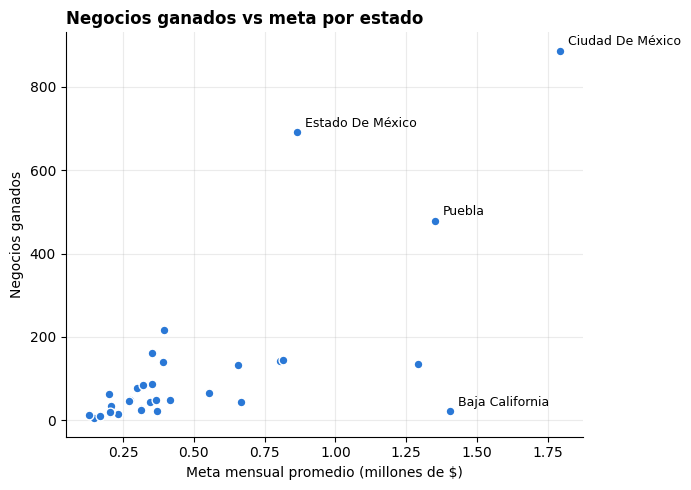

Correlación de Spearman: 0.70  (n = 32 estados)


In [ ]:
# 7. ¿Los estados con más negocios ganados son los de mayor meta?
ganados_estado = vn[(vn['resultado'] == 'Ganado') & (vn['estado'] != 'Desconocido')].groupby('estado').size()
comp = pd.DataFrame({'negocios_ganados': ganados_estado, 'meta_promedio': mt.groupby('estado')['meta'].mean()}).dropna()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(comp['meta_promedio'] / 1e6, comp['negocios_ganados'], color=AZUL, s=40, edgecolor='white')
for est in list(comp.sort_values('negocios_ganados').tail(3).index) + ['Baja California']:
    ax.annotate(est, (comp.loc[est, 'meta_promedio'] / 1e6, comp.loc[est, 'negocios_ganados']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)
ax.set_xlabel('Meta mensual promedio (millones de $)')
ax.set_ylabel('Negocios ganados')
ax.set_title('Negocios ganados vs meta por estado')
plt.tight_layout()
plt.show()

print(f"Correlación de Spearman: {comp['negocios_ganados'].corr(comp['meta_promedio'], method='spearman'):.2f}  (n = {len(comp)} estados)")

## Hallazgos del EDA

Ventas_Negadas_CRM
- 5,268 negocios de 32 estados (169 sin estado) creados entre ago-2025 y sep-2026. Septiembre está incompleto (los datos llegan al 4-sep), no interpretarlo como caída.
- Resultado: 77.8% ganados, 17.8% perdidos y 4.4% sin resultado (228 abiertos). Sobre negocios ganados+perdidos, la tasa de éxito es 81.4%.
- Geografía: CDMX (960), Estado de México (750) y Puebla (612) suman ~46% de los negocios; el top 10 concentra el 73.5%. La tasa de ganados es mayor en CDMX y Edo. Méx. (94%) y menor en Nuevo León (70%) y Jalisco (75%).
- Motivos de pérdida: *Insolvente* (31%) e *Inventario* (28%) explican casi 6 de cada 10 pérdidas; después, *Sin respuesta* (16%). Un 9% de los perdidos no tiene motivo. El inventario es un motivo accionable por la empresa, a diferencia de la insolvencia del cliente.
- Tendencia: la creación de negocios crece: entre 200 y 460 por mes hasta marzo-2026 vs. 400 a 730 de abril a agosto de 2026 (récord en agosto).
- Tiempo de cierre: la mayoría cierra muy rápido (mediana ≈ 0 días, 75% en ≤ 3 días) con una cola larga de hasta un año. El 42% de cierres con fecha anterior a la creación es un problema de calidad de datos (punto 3 arriba).

Metas
- 756 registros = 32 estados × 24 meses (ene-2025 a dic-2026), sin duplicados.
- Muy asimétrica: mediana $359 mil vs. media $520 mil (rango $0 a $2.53 M). Los 5 estados con mayor meta (CDMX, Baja California, Puebla, Jalisco, Edo. Méx.) suman el 41% del total.
- La meta 2026 es 22.7% mayor que la de 2025 y crece de forma constante mes a mes. La única ruptura es jul-2025 (de $16.0 M a $13.3 M): baja en 27 de 32 estados, es decir, un cambio general de criterio y no un problema de un estado.

Relación entre hojas
- Los estados con más negocios ganados suelen ser los de mayor meta (Spearman = 0.70).
- Baja California es la excepción llamativa: 2ª meta más alta ($1.4 M/mes) pero solo 32 negocios en el CRM (22 ganados). O el CRM no captura bien ese estado o vende por otro canal; hay que preguntarlo antes de cualquier comparación meta vs. ventas.
